In [ ]:
%load_ext autoreload
%autoreload 2
from hyperparams import *
from tasks import *
from plot import *
from model import *
from sklearn.metrics import classification_report, precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
# download_data()

In [20]:
mitdb, pwave = get_records(mitdb_dir, pwave_dir)

In [21]:
targets = []

In [22]:
# 전체 데이터를 저장할 리스트 초기화
all_segments = []
all_features = []
all_labels = []

# record별 전처리
for record in mitdb:
# for record in targets:
    # load ECG signal & annotations
    signals, fields = load_ECG_signal(record)
    signals = np.squeeze(signals)
    annotations = load_ECG_annotations(record=record, dir=mitdb_dir, extension='atr')
    
    # bandpass & R-peak detection with wavelet
    bpsig = bandpass_filter(signals)
    rpeaks = get_rpeaks(bpsig) 

    # segmentation
    segments = segment_heartbeats(bpsig, rpeaks) 

    # fill Nan, IQR clipping, remove constant features
    segments = fill_nan(segments)
    segments = IQR_clipping(segments) 
    segments = remove_const_features(segments)

    # P-peak detection
    ppeaks = get_ppeaks(record, bpsig, rpeaks)
    
    # remove 1st and last R-peak & match P,R peaks
    rpeaks = rpeaks[1:-1]
    ppeaks = match_pr(rpeaks, ppeaks)

    # feature extraction for 2nd input
    extracted_features = extract_features(bpsig, ppeaks, rpeaks)


    # normalization
    extracted_features = feature_scaling(extracted_features)
    segments = feature_scaling(segments)

    # label extraction & grouping
    labels = extract_labels(rpeaks, annotations, record)
    labels = list(map(group_labels, labels))

    # 데이터를 리스트에 추가
    all_segments.append(segments)
    all_features.append(extracted_features)
    all_labels.append(labels)
    
    
x1 = np.concatenate(all_segments, axis=0)
x2 = np.concatenate(all_features, axis=0)
y = np.concatenate(all_labels, axis=0)

print("Segments(x1) Shape:", x1.shape)
print("Extracted Features(x2) Shape:", x2.shape)
print("Labels(y) Shape:", y.shape)


rpeak: 649806, ann_idx: 1824 ann_sample length:1824, ann_symbol length:1824
rpeak: 649740, ann_idx: 2312 ann_sample length:2312, ann_symbol length:2312
rpeak: 649792, ann_idx: 2094 ann_sample length:2094, ann_symbol length:2094
rpeak: 649748, ann_idx: 2301 ann_sample length:2301, ann_symbol length:2301
rpeak: 649795, ann_idx: 2098 ann_sample length:2098, ann_symbol length:2098
rpeak: 649727, ann_idx: 2133 ann_sample length:2133, ann_symbol length:2133
rpeak: 649792, ann_idx: 1890 ann_sample length:1890, ann_symbol length:1890
Segments(x1) Shape: (129386, 300)
Extracted Features(x2) Shape: (129386, 16)
Labels(y) Shape: (129386,)


In [23]:
# data split
x1_train, x1_test_val, x2_train, x2_test_val, y_train, y_test_val = train_test_split(x1, x2, y, test_size=0.3, random_state=seed, stratify=y)
x1_val, x1_test, x2_val, x2_test, y_val, y_test = train_test_split(x1_test_val, x2_test_val, y_test_val, test_size=0.5, random_state=seed, stratify=y_test_val)


In [24]:
# one-hot encoding
y_train_oh, class_names = one_hot_encoder(y_train)
y_val_oh, _ = one_hot_encoder(y_val)
y_test_oh, _ = one_hot_encoder(y_test)

In [29]:
# model initialization
x1_shape = (x1_train.shape[1], 1)
x2_shape = (x2_train.shape[1],)
n_classes = y_train_oh.shape[1]
model = CNNModel(x1_shape, x2_shape, n_classes)   

In [30]:
# model training
model.fit([x1_train, x2_train], y_train_oh, [x1_val, x2_val], y_val_oh, y_train)

2831/2831 ━━━━━━━━━━━━━━━━━━━━ 72s 24ms/step - accuracy: 0.7027 - loss: 2.3116 - val_accuracy: 0.8628 - val_loss: 0.5550


In [31]:
# model evaluation
test_loss, test_accuracy = model.evaluate([x1_test,x2_test], y_test_oh)
print(f"Test accuracy: {test_accuracy:.4f}")

607/607 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8630 - loss: 0.5618
Test accuracy: 0.8652


607/607 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step

Class-wise Performance:
              precision    recall  f1-score   support

      Atrial       0.86      0.56      0.68       621
      Normal       0.85      0.98      0.91     12405
       Other       0.92      0.80      0.86      5205
 Ventricular       0.59      0.14      0.23      1177

    accuracy                           0.87     19408
   macro avg       0.81      0.62      0.67     19408
weighted avg       0.86      0.87      0.85     19408

Class: Atrial
  Precision: 0.8600
  Recall: 0.5636
  F1-Score: 0.6809
  Specificity: 0.9970

Class: Normal
  Precision: 0.8523
  Recall: 0.9780
  F1-Score: 0.9108
  Specificity: 0.6998

Class: Other
  Precision: 0.9234
  Recall: 0.7963
  F1-Score: 0.8552
  Specificity: 0.9758

Class: Ventricular
  Precision: 0.5935
  Recall: 0.1402
  F1-Score: 0.2268
  Specificity: 0.9938



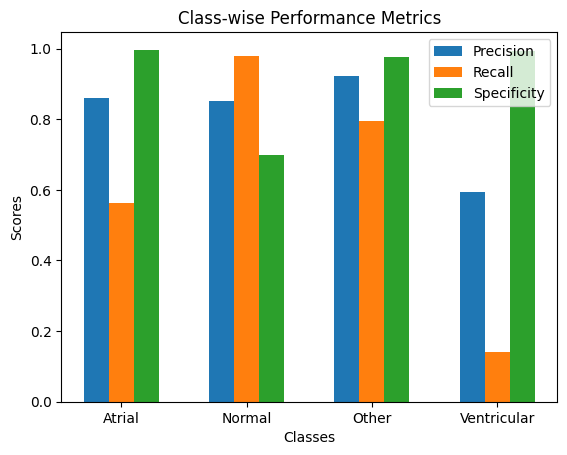

In [ ]:
# prediction
y_pred = model.predict([x1_test, x2_test])
y_test = np.argmax(y_test_oh, axis=1)  

# report
print("\nClass-wise Performance:")
print(classification_report(y_test, y_pred, target_names=class_names))

# get precision, recall, f1-score, specificity
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=range(len(class_names)))
specificity = calc_specificity(y_test, y_pred, class_names)

# 결과 출력
for i, class_name in enumerate(class_names):
    print(f"Class: {class_name}")
    print(f"  Precision: {precision[i]:.4f}")
    print(f"  Recall: {recall[i]:.4f}")
    print(f"  F1-Score: {f1[i]:.4f}")
    print(f"  Specificity: {specificity[i]:.4f}")
    print()

# histogram
x = np.arange(len(class_names))
width = 0.2

plt.bar(x - width, precision, width=width, label="Precision")
plt.bar(x, recall, width=width, label="Recall")
plt.bar(x + width, specificity, width=width, label="Specificity")
plt.xlabel("Classes")
plt.ylabel("Scores")
plt.title("Class-wise Performance Metrics")
plt.xticks(x, class_names)
plt.legend()
plt.show()
